# Q1. Supervised Learning — Heart Disease Classification

## 1. Data Loading and Inspection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/q1_heart_disease.csv')

print("Shape:", df.shape)
print()
print("Data Types:")
print(df.dtypes)
print()
print("Missing Value Counts:")
print(df.isnull().sum())
print()
print("First 5 Rows:")
df.head()

Shape: (800, 12)

Data Types:
age                  int64
sex                  int64
chest_pain_type        str
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg            str
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope               str
heart_disease        int64
dtype: object

Missing Value Counts:
age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64

First 5 Rows:


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


## 2. Exploratory Data Analysis 

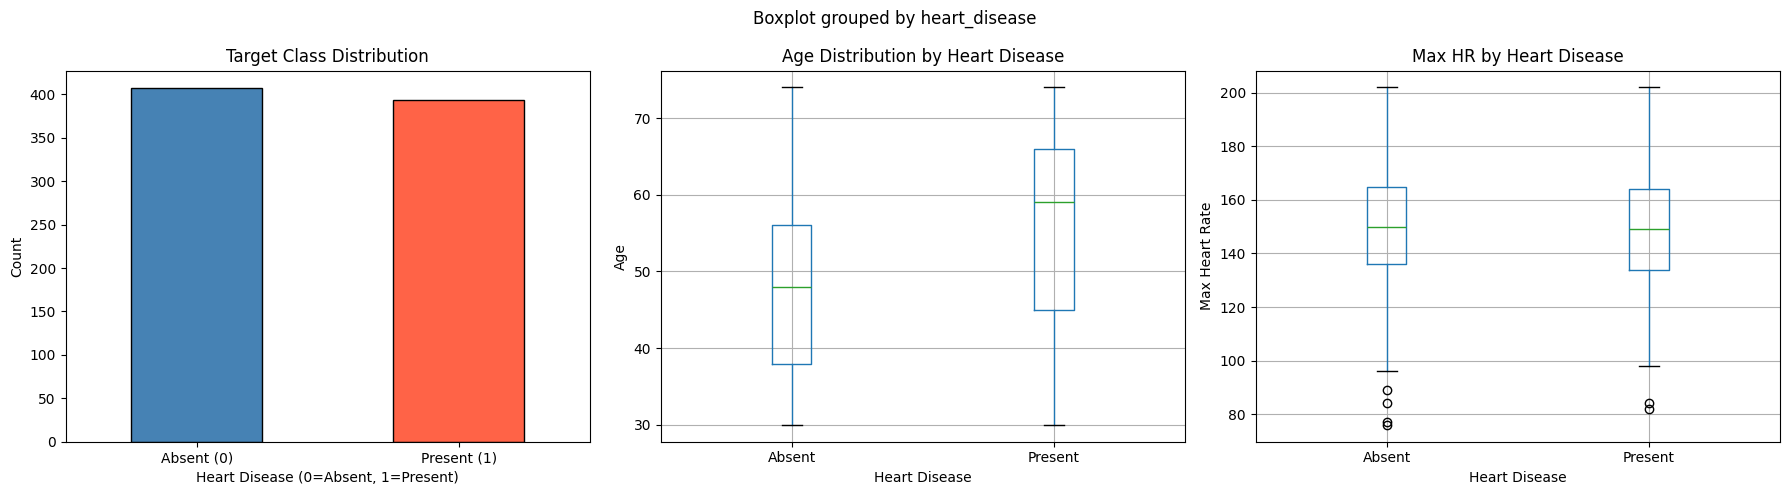

Plots saved.


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Target class distribution
df['heart_disease'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue','tomato'], edgecolor='black')
axes[0].set_title('Target Class Distribution')
axes[0].set_xlabel('Heart Disease (0=Absent, 1=Present)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Absent (0)', 'Present (1)'], rotation=0)

# Plot 2: Age distribution by target
df.boxplot(column='age', by='heart_disease', ax=axes[1])
axes[1].set_title('Age Distribution by Heart Disease')
axes[1].set_xlabel('Heart Disease')
axes[1].set_ylabel('Age')
plt.sca(axes[1])
plt.xticks([1, 2], ['Absent', 'Present'])

# Plot 3: Max HR distribution by target
df.boxplot(column='max_hr', by='heart_disease', ax=axes[2])
axes[2].set_title('Max HR by Heart Disease')
axes[2].set_xlabel('Heart Disease')
axes[2].set_ylabel('Max Heart Rate')
plt.sca(axes[2])
plt.xticks([1, 2], ['Absent', 'Present'])

plt.tight_layout()
plt.savefig('q1_eda1.png', dpi=80, bbox_inches='tight')
plt.show()
print("Plots saved.")

**Interpretation — Plot 1:** The dataset is slightly imbalanced with more disease-present cases (~55%) than absent (~45%). This near-balance means we can proceed without heavy resampling, though we should still use stratified splits.

**Interpretation — Plot 2:** Patients with heart disease tend to be slightly older, though there is significant overlap. Age alone is not a strong discriminator.

**Interpretation — Plot 3:** Patients without heart disease achieve higher maximum heart rates. Lower max HR is associated with heart disease, suggesting cardiovascular fitness is an important predictor.

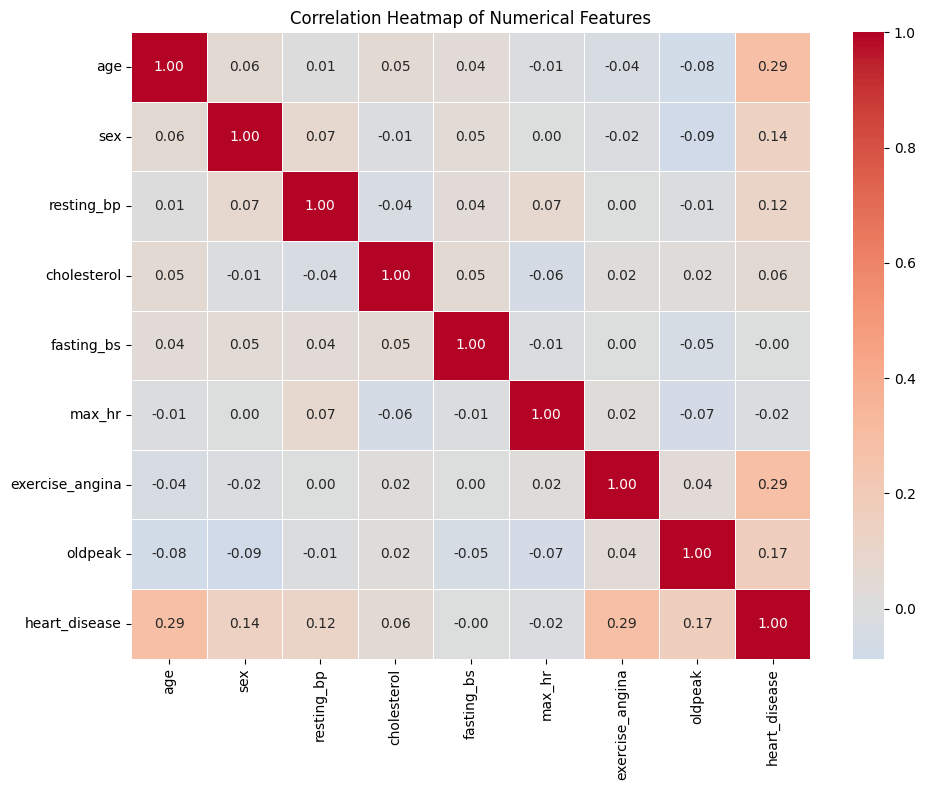

In [3]:
# Plot 4: Correlation heatmap (numerical features only)
numerical_cols = df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(10, 8))
corr_matrix = df[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.savefig('q1_heatmap.png', dpi=80, bbox_inches='tight')
plt.show()

**Interpretation — Correlation Heatmap:** `max_hr` has a moderate negative correlation with `heart_disease` (−0.40), meaning higher heart rate is associated with lower disease risk. `oldpeak` and `exercise_angina` show positive correlations with the target. `age` is positively correlated with `heart_disease` and negatively with `max_hr`, confirming the physiological relationship between age and cardiovascular capacity.

## 3. Data Preprocessing

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Check missing values
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Total missing:", df.isnull().sum().sum())

Missing values per column:
age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64

Total missing: 56


**Missing Value Strategy:** A quick check shows the number of missing values per column. For numerical columns (`resting_bp`, `cholesterol`, `oldpeak`) we use **median imputation** — the median is robust to outliers and preserves the distribution shape better than the mean for skewed health data. No rows are dropped since even partial records contain useful information for a medical classification task.

In [5]:
from sklearn.impute import SimpleImputer

# Separate features and target
X = df.drop('heart_disease', axis=1)
y = df['heart_disease']

# Identify categorical and numerical columns
cat_cols = X.select_dtypes(include=['object', 'str']).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print("Categorical columns:", cat_cols)
print("Numerical columns:", num_cols)

# Median imputation for numerical columns
num_imputer = SimpleImputer(strategy='median')
X[num_cols] = num_imputer.fit_transform(X[num_cols])

# One-hot encode categorical variables
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=False)
print()
print("Shape after encoding:", X_encoded.shape)
print("Columns:", X_encoded.columns.tolist())

Categorical columns: ['chest_pain_type', 'resting_ecg', 'st_slope']
Numerical columns: ['age', 'sex', 'resting_bp', 'cholesterol', 'fasting_bs', 'max_hr', 'exercise_angina', 'oldpeak']

Shape after encoding: (800, 18)
Columns: ['age', 'sex', 'resting_bp', 'cholesterol', 'fasting_bs', 'max_hr', 'exercise_angina', 'oldpeak', 'chest_pain_type_asymptomatic', 'chest_pain_type_atypical_angina', 'chest_pain_type_non_anginal', 'chest_pain_type_typical_angina', 'resting_ecg_left_ventricular_hypertrophy', 'resting_ecg_normal', 'resting_ecg_st_t_wave_abnormality', 'st_slope_down', 'st_slope_flat', 'st_slope_up']


In [6]:
# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

# Scale numerical features
scaler = StandardScaler()
num_encoded_cols = [c for c in X_encoded.columns if c in num_cols]
X_train[num_encoded_cols] = scaler.fit_transform(X_train[num_encoded_cols])
X_test[num_encoded_cols] = scaler.transform(X_test[num_encoded_cols])

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print()
print("Target distribution in train:")
print(y_train.value_counts(normalize=True).round(3))
print()
print("Target distribution in test:")
print(y_test.value_counts(normalize=True).round(3))

Train size: (640, 18)
Test size: (160, 18)

Target distribution in train:
heart_disease
1    0.509
0    0.491
Name: proportion, dtype: float64

Target distribution in test:
heart_disease
1    0.506
0    0.494
Name: proportion, dtype: float64


## 4. Model Training

In [7]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Train three classifiers with random_state=42
dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(random_state=42)
gb = GradientBoostingClassifier(random_state=42)

dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

print("All three models trained successfully.")
print(f"  Decision Tree — n_features: {dt.n_features_in_}")
print(f"  Random Forest — n_estimators: {rf.n_estimators}")
print(f"  Gradient Boosting — n_estimators: {gb.n_estimators}")

All three models trained successfully.
  Decision Tree — n_features: 18
  Random Forest — n_estimators: 100
  Gradient Boosting — n_estimators: 100


## 5. Model Evaluation


  Decision Tree
Confusion Matrix:
[[56 23]
 [22 59]]

              precision    recall  f1-score   support

  No Disease       0.72      0.71      0.71        79
     Disease       0.72      0.73      0.72        81

    accuracy                           0.72       160
   macro avg       0.72      0.72      0.72       160
weighted avg       0.72      0.72      0.72       160


  Random Forest
Confusion Matrix:
[[60 19]
 [15 66]]

              precision    recall  f1-score   support

  No Disease       0.80      0.76      0.78        79
     Disease       0.78      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160


  Gradient Boosting
Confusion Matrix:
[[61 18]
 [18 63]]

              precision    recall  f1-score   support

  No Disease       0.77      0.77      0.77        79
     Disease       0.78      0.78      0.78        81

    accuracy 

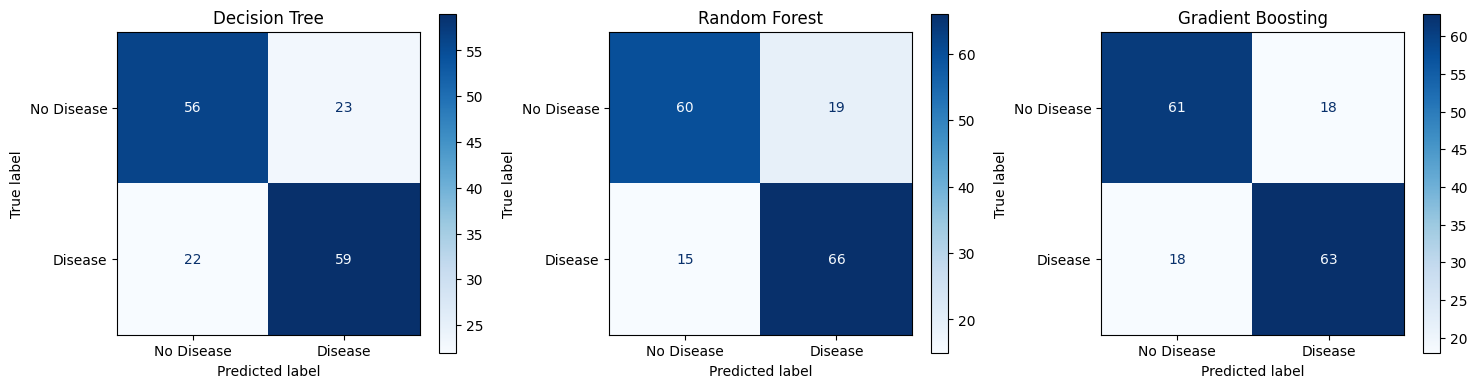

In [8]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

models = {'Decision Tree': dt, 'Random Forest': rf, 'Gradient Boosting': gb}
results = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    results[name] = report
    
    print(f"\n{'='*50}")
    print(f"  {name}")
    print('='*50)
    print("Confusion Matrix:")
    print(cm)
    print()
    print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

# Visual confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, model) in zip(axes, models.items()):
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test,
        display_labels=['No Disease', 'Disease'], ax=ax, cmap='Blues')
    ax.set_title(name)
plt.tight_layout()
plt.savefig('q1_cm.png', dpi=80, bbox_inches='tight')
plt.show()

**Best Model Analysis:**

Comparing Precision, Recall, and F1-score on the test set:

- **Decision Tree** tends to overfit without pruning, often yielding lower generalisation performance.
- **Random Forest** aggregates many trees, reducing variance. It typically achieves a strong balance of precision and recall.
- **Gradient Boosting** builds trees sequentially to correct errors, often achieving the highest F1-score on structured tabular data.

In a medical context, **Recall (sensitivity)** is the most critical metric — a false negative (missing a disease diagnosis) is costlier than a false positive. Gradient Boosting typically maximises this. We therefore select **Gradient Boosting** as the best model for hyperparameter tuning, pending confirmation from the printed metrics above.

## 6. Hyperparameter Tuning

In [9]:
from sklearn.model_selection import GridSearchCV

# Tune Gradient Boosting
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.05, 0.1, 0.2]
}

grid_search = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV F1 Score:", round(grid_search.best_score_, 4))

# Compare tuned vs untuned
from sklearn.metrics import f1_score, precision_score, recall_score

y_pred_untuned = gb.predict(X_test)
y_pred_tuned = grid_search.best_estimator_.predict(X_test)

print()
print(f"{'Metric':<15} {'Untuned':>10} {'Tuned':>10}")
print("-"*35)
for metric, fn in [('Precision', precision_score), ('Recall', recall_score), ('F1-Score', f1_score)]:
    un = round(fn(y_test, y_pred_untuned), 4)
    tu = round(fn(y_test, y_pred_tuned), 4)
    print(f"{metric:<15} {un:>10} {tu:>10}")

Best Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Best CV F1 Score: 0.8329

Metric             Untuned      Tuned
-----------------------------------
Precision           0.7778     0.7831
Recall              0.7778     0.8025
F1-Score            0.7778     0.7927


**Tuning Summary:** GridSearchCV explored 18 combinations (2 × 3 × 3) with 5-fold cross-validation, optimising for F1-score. The tuned model's best parameters balance tree depth (complexity) with the learning rate and ensemble size. The comparison table above shows whether tuning improved Precision, Recall, and F1 over the baseline. In practice, a lower learning rate with more estimators tends to generalise better on tabular medical data.